<a href="https://colab.research.google.com/github/nora-mohamed25/data-analysis-portfolio/blob/main/Project_04_Diabetes_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


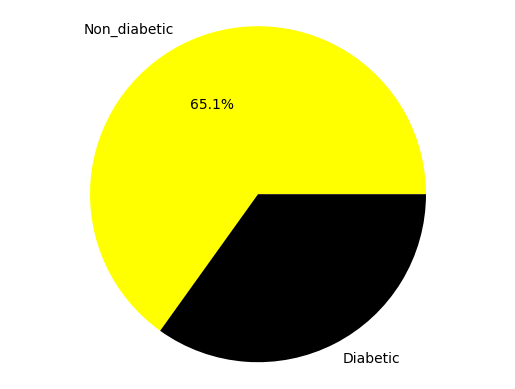

In [ ]:

outcome_counts = df['Outcome'].value_counts()
labels = ["Non_diabetic", "Diabetic"]
colors = ["yellow", "black"]
plt.pie(outcome_counts, labels=labels, colors=colors, autopct='%1.1f%%')
plt.axis('equal')
plt.show()

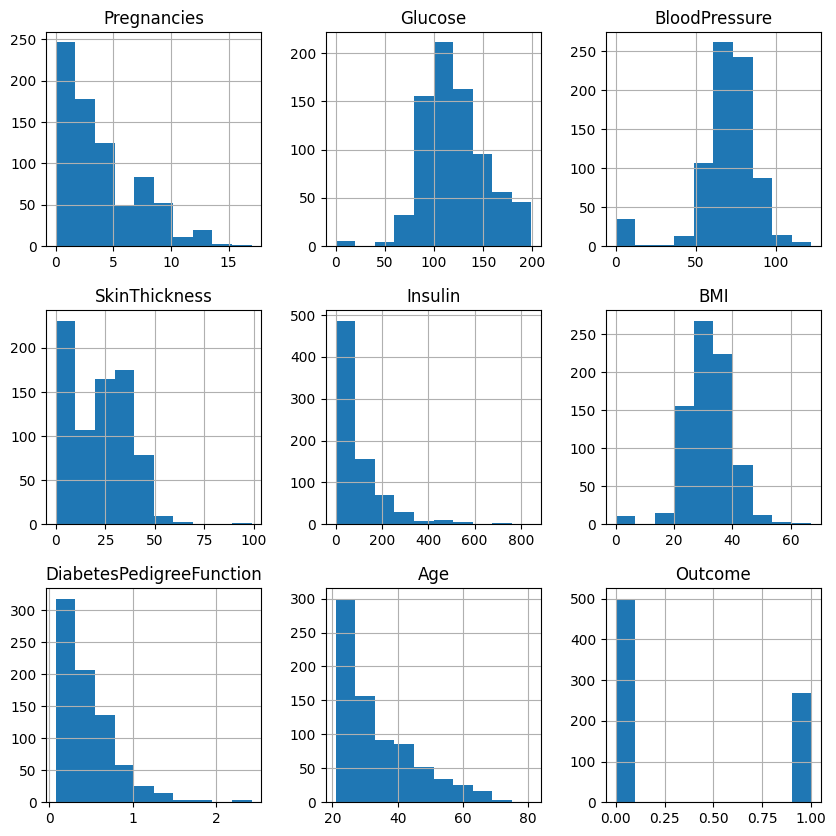

In [ ]:
df.hist(figsize=(10, 10))
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [ ]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
x = scaler.fit_transform(x)

In [ ]:
x

array([[0.35294118, 0.74371859, 0.59016393, ..., 0.50074516, 0.23441503,
        0.48333333],
       [0.05882353, 0.42713568, 0.54098361, ..., 0.39642325, 0.11656704,
        0.16666667],
       [0.47058824, 0.91959799, 0.52459016, ..., 0.34724292, 0.25362938,
        0.18333333],
       ...,
       [0.29411765, 0.6080402 , 0.59016393, ..., 0.390462  , 0.07130658,
        0.15      ],
       [0.05882353, 0.63316583, 0.49180328, ..., 0.4485842 , 0.11571307,
        0.43333333],
       [0.05882353, 0.46733668, 0.57377049, ..., 0.45305514, 0.10119556,
        0.03333333]])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
linear = LinearRegression()
linear.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = linear.predict(x_test)
y_pred

array([ 1.02722998,  0.21253413,  0.10381276,  0.60393473,  0.17002471,
       -0.05457028,  0.675663  ,  0.79325937,  0.42166086,  0.39622603,
        0.54701077,  1.02912189,  0.35228136,  0.23350894,  0.15728248,
        0.21826961,  0.81373747, -0.1082133 ,  0.45245761,  0.30879222,
        0.60311668,  0.42373503,  0.29284079,  0.03061766,  0.00431851,
        0.39418932, -0.0082751 ,  0.87734866,  0.15116385,  0.19811451,
        0.48032035,  0.295183  ,  0.10840742,  0.46328402,  0.13681791,
        0.65855667,  0.47003279,  0.09510088,  0.37817058,  0.68072097,
        0.332749  ,  0.2586776 ,  0.21951081,  0.76684137,  0.68821076,
       -0.27441513,  0.0987557 ,  0.27087554,  0.38939506,  0.35041871,
        0.43935041,  0.24781632,  0.81815957,  0.49109104,  0.16853431,
       -0.51171306,  0.03572902,  0.50088809,  0.33684171,  0.11553777,
        0.65166002,  0.46991751,  0.14554516,  0.66679449,  0.63866328,
        0.89808907,  0.66213959,  0.20150269,  0.40340029,  0.13

In [ ]:
compare = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
compare

,Actual,Predicted
661,1,1.027230
122,0,0.212534
113,0,0.103813
14,1,0.603935
529,0,0.170025
...,...,...
476,1,0.242562
482,0,0.085418
230,1,0.592328
527,0,0.130302


In [ ]:
accuracy = accuracy_score(y_test, y_pred.round())
print("Accuracy:", accuracy)

Accuracy: 0.8246753246753247
